# Hiperparametrizacion GridSearch - Vinos

1. Preparación de Datos
2. Hiperparametrización con validación cruzada
3. Comparación de modelos
4. Guardar el mejor Modelo

In [1]:
# Cargamos librerías principales
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Preparación de Datos


In [2]:
# Cargamos los datos
data = pd.read_csv("wine_data.csv")
data.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,Id,tipo,calidad
0,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,1.0,tinto,Mala
1,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,2.0,tinto,Mala
2,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,3.0,tinto,Buena
3,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,4.0,tinto,Mala
4,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5.0,tinto,Mala


In [3]:
# Conocemos los datos
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4979 entries, 0 to 4978
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         4979 non-null   float64
 1   volatile acidity      4979 non-null   float64
 2   citric acid           4979 non-null   float64
 3   residual sugar        4979 non-null   float64
 4   chlorides             4979 non-null   float64
 5   free sulfur dioxide   4979 non-null   float64
 6   total sulfur dioxide  4979 non-null   float64
 7   density               4979 non-null   float64
 8   pH                    4979 non-null   float64
 9   sulphates             4979 non-null   float64
 10  alcohol               4979 non-null   float64
 11  Id                    1018 non-null   float64
 12  tipo                  4979 non-null   object 
 13  calidad               4979 non-null   object 
dtypes: float64(12), object(2)
memory usage: 544.7+ KB


In [4]:
# Corrección del tipo de datos object a categorías
data['tipo']=data['tipo'].astype('category')
data['calidad']=data['calidad'].astype('category')

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4979 entries, 0 to 4978
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   fixed acidity         4979 non-null   float64 
 1   volatile acidity      4979 non-null   float64 
 2   citric acid           4979 non-null   float64 
 3   residual sugar        4979 non-null   float64 
 4   chlorides             4979 non-null   float64 
 5   free sulfur dioxide   4979 non-null   float64 
 6   total sulfur dioxide  4979 non-null   float64 
 7   density               4979 non-null   float64 
 8   pH                    4979 non-null   float64 
 9   sulphates             4979 non-null   float64 
 10  alcohol               4979 non-null   float64 
 11  Id                    1018 non-null   float64 
 12  tipo                  4979 non-null   category
 13  calidad               4979 non-null   category
dtypes: category(2), float64(12)
memory usage: 476.9 KB


In [5]:
# Variables irrelevantes
data = data.drop('Id',axis=1) # eliminamos el Id por ser irrelevante, axis=1 indica que es una columna
data.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,tipo,calidad
0,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,tinto,Mala
1,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,tinto,Mala
2,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,tinto,Buena
3,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,tinto,Mala
4,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,tinto,Mala


In [6]:
# Descripción de variables numéricas
data.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
count,4979.000000,4979.000000,4979.000000,4979.000000,4979.000000,4979.000000,4979.000000,4979.000000,4979.000000,4979.000000,4979.000000
mean,7.135640,0.332267,0.320934,5.221621,0.054345,30.955312,118.614782,0.994385,3.219185,0.524386,10.561367
std,1.248562,0.160559,0.143151,4.585347,0.034388,17.804445,55.201299,0.002973,0.159831,0.143161,1.194316
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000
25%,6.400000,0.230000,0.250000,1.700000,0.037000,18.000000,84.000000,0.992000,3.110000,0.430000,9.500000
50%,6.900000,0.290000,0.310000,2.900000,0.046000,29.000000,120.000000,0.994400,3.210000,0.500000,10.400000
75%,7.600000,0.390000,0.390000,7.800000,0.060000,42.000000,157.000000,0.996600,3.320000,0.590000,11.400000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000


<Axes: >

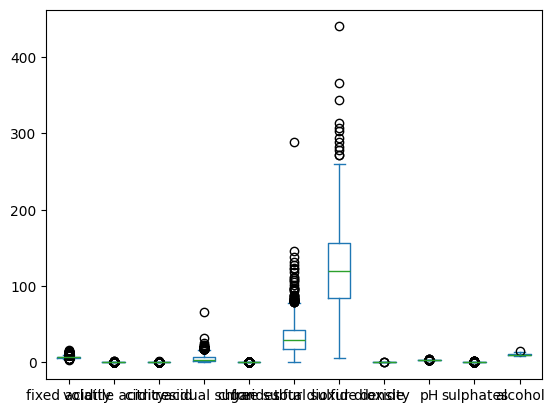

In [7]:
data.plot(kind='box')

<Axes: xlabel='tipo'>

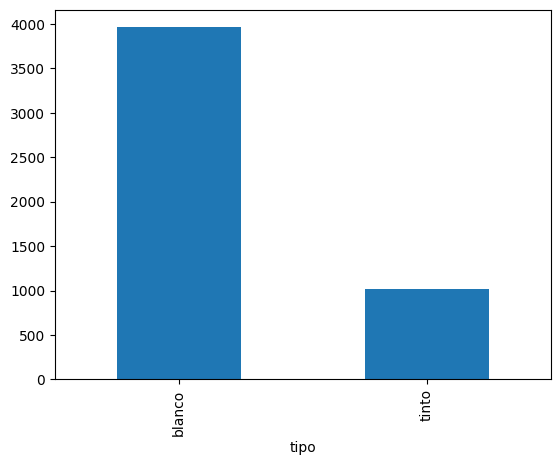

In [8]:
# Descripción variables categóricas
data['tipo'].value_counts().plot(kind='bar')

<Axes: ylabel='calidad'>

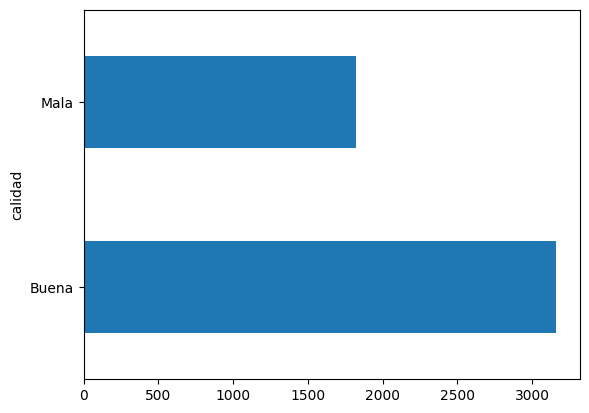

In [9]:
data['calidad'].value_counts().plot(kind='barh')

In [10]:
# Sklearn sólo analiza variables numéricas
data = pd.get_dummies(data, columns=['tipo'], drop_first=True, dtype=int)
data.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,calidad,tipo_tinto
0,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,Mala,1
1,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,Mala,1
2,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,Buena,1
3,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,Mala,1
4,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,Mala,1


In [11]:
# Se codifican las categorias de la VARIABLE OBJETIVO

from sklearn.preprocessing import LabelEncoder
labelencoder = LabelEncoder()
data["calidad"]=labelencoder.fit_transform(data["calidad"])

data.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,calidad,tipo_tinto
0,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,1,1
1,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,1,1
2,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,0,1
3,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,1,1
4,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,1,1


# 2. Hiperparametrización con validación cruzada

In [12]:
# Configuración hiperparametrización
from sklearn.model_selection import GridSearchCV, StratifiedKFold
scoring='f1_macro'
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42) # Mismos folds que en la Validación Cruzada

In [13]:
# Configuración de datos
X = data.drop("calidad", axis = 1) # Variables predictoras
Y = data['calidad'] # Variable objetivo

In [14]:
# Medida de evaluación del mejor modelo
medidas= pd.DataFrame(index=['f1 de la CV'])

# **Hiperparametrización Arbol de Clasificación**

In [15]:
# Arbol
#from sklearn.tree import DecisionTreeClassifier
#modelTree = DecisionTreeClassifier()

# Definir los hiperparametros
#criterion=['entropy','gini'] #Indice de información
#min_samples_leaf=[2,10] # Cantidad de registros por hoja
#max_depth=[None,20,50] #Niveles de profundidad

# La idea es evitar probar por probar, ahorrar pruebas

In [16]:
# Hiperparametrización
#param_grid = dict(criterion=criterion, min_samples_leaf=min_samples_leaf, max_depth=max_depth)
#grid = GridSearchCV(estimator=modelTree, param_grid=param_grid, scoring=scoring, cv=cv, return_train_score=True, refit=True) #diccionario, los dos del final permiten devolver las medidas de train , pero poder evaluar entre los modelos , refit para que vuelva y entrene con el 100% de los datos
#grid.fit(X, Y)

# Mejor modelo
#modelTree= grid.best_estimator_

# Mejores párametros
#print( grid.best_params_)

In [17]:
# Revisar overfitting y underfitting para el mejor modelo
#print("Train CV:", grid.cv_results_["mean_train_score"][grid.best_index_])
#print("Test CV:", grid.cv_results_["mean_test_score"][grid.best_index_])

In [18]:
# Comparación de medidas
#medidas['Tree']=grid.best_score_
#medidas

In [19]:
# Mejor modelo
#from sklearn.tree import plot_tree
#plt.figure(figsize=(5,5))
#plot_tree(modelTree, feature_names=X.columns.values, class_names=labelencoder.classes_, rounded=True, filled=True, fontsize=8)
#plt.show()

# **Hiperparametrización para Random Forest**

In [20]:
# RF
#from sklearn.ensemble import RandomForestClassifier
#model_rf = RandomForestClassifier()

# Definir los hiperparametros
#n_estimators=[2,5,15] #Cantidad de árboles
#criterion=['entropy','gini'] #Indice de información
#min_samples_leaf=[2,10] # Cantidad de registros por hoja
#max_depth=[None,20,50] #Niveles de profundidad

In [21]:
# Hiperparametrización
#param_grid_rf = dict(n_estimators=n_estimators, criterion=criterion,
#                     min_samples_leaf=min_samples_leaf, max_depth=max_depth)

#grid_rf = GridSearchCV(estimator=model_rf, param_grid=param_grid_rf, scoring=scoring,
#                       cv=cv, return_train_score=True, refit=True, n_jobs=-1)
#grid_rf.fit(X, Y)

# Mejor modelo
#model_rf = grid_rf.best_estimator_

# Mejores párametros
#print(grid_rf.best_params_)

In [22]:
# Revisar overfitting y underfitting para el mejor modelo
#print("Train CV:", grid_rf.cv_results_["mean_train_score"][grid_rf.best_index_])
#print("Test CV:", grid_rf.cv_results_["mean_test_score"][grid_rf.best_index_])

In [23]:
# Comparación de medidas
#medidas['RF']=grid_rf.best_score_
#medidas

In [24]:
#plot_tree(model_rf.estimators_[0], feature_names=X.columns.values,
#          class_names=labelencoder.classes_, rounded=True, filled=True,
#          fontsize=8, max_depth=3)

# **Hiperparametrización Knn para Clasificación**

In [25]:
# Normalizacion las variables numéricas (las dummies no se normalizan)
# Necesaria para Knn, NN y SVM: sin normalizar, la red no aprende (variables con escalas muy distintas)
from sklearn.preprocessing import MinMaxScaler

min_max_scaler = MinMaxScaler()
variables_numericas=['fixed acidity', 'volatile acidity', 'citric acid',
                     'residual sugar', 'chlorides', 'free sulfur dioxide',
                     'total sulfur dioxide', 'density', 'pH', 'sulphates',
                     'alcohol']
min_max_scaler.fit(X[variables_numericas]) #Ajuste de los parametros: max - min
X[variables_numericas]= min_max_scaler.transform(X[variables_numericas])
X.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,tipo_tinto
0,0.330579,0.533333,0.000000,0.030675,0.147841,0.083333,0.140553,0.186813,0.372093,0.258427,0.260870,1
1,0.330579,0.453333,0.024096,0.026074,0.137874,0.048611,0.110599,0.190669,0.418605,0.241573,0.260870,1
2,0.611570,0.133333,0.337349,0.019939,0.109635,0.055556,0.124424,0.209948,0.341085,0.202247,0.260870,1
3,0.297521,0.413333,0.000000,0.019939,0.111296,0.034722,0.064516,0.206092,0.612403,0.191011,0.202899,1
4,0.297521,0.386667,0.000000,0.018405,0.109635,0.041667,0.078341,0.206092,0.612403,0.191011,0.202899,1


In [26]:
# KNN
#from sklearn.neighbors  import KNeighborsClassifier
#modelKnn = KNeighborsClassifier()

# Definir los hiperparametros
#n_neighbors=[1,3,5,7]
#metric=['euclidean','minkowski']

# Grid
#param_grid = dict(n_neighbors=n_neighbors, metric=metric)
#grid = GridSearchCV(estimator=modelKnn, param_grid=param_grid, scoring=scoring, cv=cv, return_train_score=True, refit=True)
#grid.fit(X, Y)

# Mejor modelo
#modelKnn= grid.best_estimator_

# Mejores párametros
#print( grid.best_params_)

In [27]:
# Revisar overfitting y underfitting
#print("Train CV:", grid.cv_results_["mean_train_score"][grid.best_index_])
#print("Test CV:", grid.cv_results_["mean_test_score"][grid.best_index_])


# Medida de evaluación del mejor modelo
#medidas['Knn']=grid.best_score_
#medidas

# **Hiperparametrización Red Neuronal**

In [28]:
# Red Neuronal

from sklearn.neural_network import MLPClassifier
modelNN = MLPClassifier()

# Definir los parametros (punto de partida, la VC: logistic, (50,25,12), lr 0.02 -> f1 0.739)
random_state=[3] # Semilla para generar número pseudoaleatorios (la misma de la VC)
solver=['adam'] # Regla de aprendizaje ['adam','sgd','lbfgs']
learning_rate=['constant'] # tasa de aprendizaje
learning_rate_init=[0.001, 0.01, 0.02] # valor tasa de aprendizaje
activation=['logistic', 'tanh', 'relu'] # 'identity’, ‘logistic’, ‘tanh’, ‘relu’
hidden_layer_sizes=[(50,25,12),(100,50),(30,15)] # tuplas = varias capas ocultas: (50,25,12) son 3 capas
alpha=[0.0001, 0.01] # regularización L2: penaliza pesos grandes para controlar el overfitting
max_iter = [500] # iteraciones

# Grid: 3 x 3 x 3 x 2 = 54 combinaciones x 10 folds
param_grid = dict(random_state=random_state,solver=solver,activation=activation, hidden_layer_sizes=hidden_layer_sizes, max_iter=max_iter, learning_rate=learning_rate,
                  learning_rate_init=learning_rate_init, alpha=alpha)
grid = GridSearchCV(estimator=modelNN, param_grid=param_grid, scoring=scoring, cv=cv, return_train_score=True, refit=True, n_jobs=-1)
grid.fit(X, Y)

# Mejor modelo
modelNN= grid.best_estimator_

# Mejores párametros
print( grid.best_params_)

{'activation': 'relu', 'alpha': 0.01, 'hidden_layer_sizes': (100, 50), 'learning_rate': 'constant', 'learning_rate_init': 0.001, 'max_iter': 500, 'random_state': 3, 'solver': 'adam'}


In [29]:
# Revisar overfitting y underfitting
print("Train CV:", grid.cv_results_["mean_train_score"][grid.best_index_])
print("Test CV:", grid.cv_results_["mean_test_score"][grid.best_index_])


# Medida de evaluación del mejor modelo
medidas['NN']=grid.best_score_
medidas

Train CV: 0.7681553629344663
Test CV: 0.7490668408434739


,NN
f1 de la CV,0.749067


# **Hiperparametrización SVM para Clasificación**

In [30]:
# SVM
#from sklearn.svm import SVC
#modelSVM = SVC()

# Definir los hiperparametros
#C=[10] #Margen blando 1
#kernel=['linear','poly'] #'linear', 'poly', 'rbf', 'sigmoid'
#gamma=['auto']

# Grid
#param_grid = dict(C=C, kernel=kernel,gamma=gamma)
#grid = GridSearchCV(estimator=modelSVM, param_grid=param_grid, scoring=scoring, cv=cv, return_train_score=True, refit=True)
#grid.fit(X, Y)

# Mejor modelo
#modelSVM= grid.best_estimator_

# Mejores párametros
#print( grid.best_params_)


In [31]:
# Revisar overfitting y underfitting
#print("Train CV:", grid.cv_results_["mean_train_score"][grid.best_index_])
#print("Test CV:", grid.cv_results_["mean_test_score"][grid.best_index_])


# Medida de evaluación del mejor modelo
#edidas['SVM']=grid.best_score_
#medidas

# 3. Selección del mejor modelo

* En la validación cruzada la red neuronal fue el mejor modelo (f1 macro 0.739), por eso es el modelo que se hiperparametriza.
* Con GridSearch el mejor modelo es una red con activación relu, dos capas ocultas (100, 50), tasa de aprendizaje 0.001 y regularización alpha=0.01. El f1 macro sube de 0.739 a 0.749.
* Overfitting: la diferencia entre train (0.768) y test (0.749) es de 1.9 puntos, menor a 5, no hay overfitting.
* La regularización (alpha) es la que permite usar una red más grande sin sobreajustar.

In [32]:
medidas

,NN
f1 de la CV,0.749067


In [33]:
# Modelo seleccionado
modelo_final=modelNN

# 4. Guardamos el modelo

In [34]:
import pickle
filename = 'modelo-cla-vinos-hiper.pkl'
variables= X.columns._values
pickle.dump([modelo_final,labelencoder,variables,min_max_scaler], open(filename, 'wb'))